In [20]:
from template_engine import build_case

params = {
    "solver":   "icoFoam",
    "template": "cavity",
    "nu":       1e-5,
    "U":        1.0,
    "rho":      1.0,
    "endTime":  0.5,
    "deltaT":   0.005,
    "Re":       1000,
}

case_dir = build_case(params)
print("Case built at:", case_dir)

Case built at: /tmp/foam_cavity_3nh7n6lt


In [21]:
import subprocess
result = subprocess.run(["cat", f"{case_dir}/constant/physicalProperties"], capture_output=True, text=True)
print(result.stdout)
# Should show nu = 1e-05 with no Jinja2 {{ }} remaining

FoamFile
{
    version     2.0;
    format      ascii;
    class       dictionary;
    location    "constant";
    object      physicalProperties;
}

viscosityModel  constant;
nu              1e-05;



In [22]:
from foam_runner import run_simulation

log_lines = []
for line in run_simulation(case_dir, params):
    print(line, end="")
    log_lines.append(line)

full_log = "".join(log_lines)
print("\n--- Done ---")

=== blockMesh ===
/*---------------------------------------------------------------------------*\
  =========                 |
  \\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\    /   O peration     | Website:  https://openfoam.org
    \\  /    A nd           | Version:  13
     \\/     M anipulation  |
\*---------------------------------------------------------------------------*/
Build  : 13-441953dfbb42
Exec   : blockMesh
Date   : May 06 2026
Time   : 18:49:49
Host   : "pop-os"
PID    : 34181
I/O    : uncollated
Case   : /tmp/foam_cavity_3nh7n6lt
nProcs : 1
fileModificationChecking : Monitoring run-time modified files using timeStampMaster (fileModificationSkew 10)
allowSystemOperations : Allowing user-supplied system call operations

// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //
Create time

Reading "blockMeshDict"

Creating block mesh from
    "system/blockMeshDict"
No non-linear block edges defined
No non-planar block fac

In [23]:
import os

time_dirs = [
    d for d in os.listdir(case_dir)
    if d.replace(".", "").isdigit() and d != "0"
]
print("Time steps written:", sorted(time_dirs, key=float))
# Should show ['0.1', '0.2', '0.3', '0.4', '0.5'] or similar

Time steps written: ['0.5']


In [24]:
from visualizer import plot_residuals
import plotly.io as pio

fig = plot_residuals(full_log)
if fig:
    fig.show()
else:
    print("No residuals parsed — check log above for solver output")

In [26]:
from visualizer import render_results

# Create the required empty .foam file
import pathlib
foam_file = pathlib.Path(case_dir) / "case.foam"
foam_file.touch()

img = render_results(case_dir)
if img is not None:
    from IPython.display import Image
    display(Image(data=img))   # shows inline in notebook
else:
    print("Render failed")

Render failed


In [ ]:
import os

time_dirs = sorted(
    [d for d in os.listdir(case_dir)
     if d.replace(".","").isdigit() and d != "0"],
    key=float
)
print("time_dirs:", time_dirs)

u_file = os.path.join(case_dir, time_dirs[-1], "U")
print("u_file path:", u_file)
print("u_file exists:", os.path.exists(u_file))

time_dirs: ['0.5']
u_file path: /tmp/foam_cavity_3nh7n6lt/0.5/U
u_file exists: True


In [28]:
with open(u_file) as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("--- First 30 lines ---")
print("".join(lines[:30]))

Total lines: 443
--- First 30 lines ---
/*--------------------------------*- C++ -*----------------------------------*\
  =========                 |
  \\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\    /   O peration     | Website:  https://openfoam.org
    \\  /    A nd           | Version:  13
     \\/     M anipulation  |
\*---------------------------------------------------------------------------*/
FoamFile
{
    format      ascii;
    class       volVectorField;
    location    "0.5";
    object      U;
}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

dimensions      [0 1 -1 0 0 0 0];

internalField   nonuniform List<vector> 
400
(
(-0.000191938 0.000188029 0)
(-0.000644307 0.000235259 0)
(-0.00115217 0.000232065 0)
(-0.00163534 0.000221952 0)
(-0.00209058 0.00020781 0)
(-0.00250968 0.000189502 0)
(-0.00288341 0.000166759 0)
(-0.00320221 0.000139302 0)
(-0.00345618 0.000106842 0)



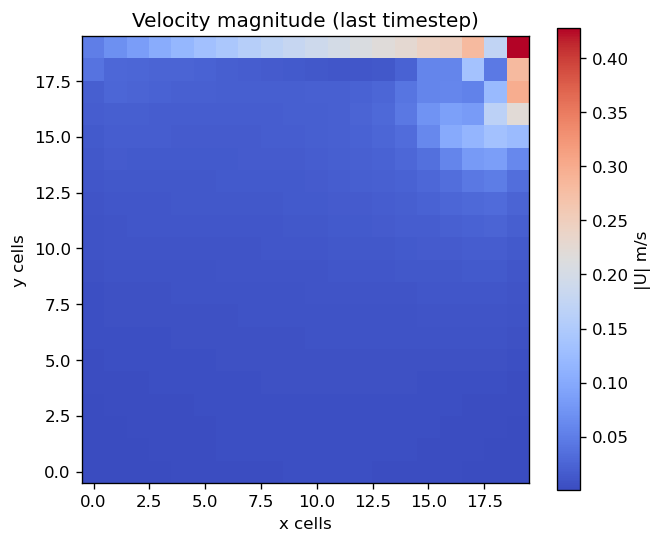

In [29]:
import importlib, visualizer
importlib.reload(visualizer)
from visualizer import render_results

img = render_results(case_dir)
if img:
    from IPython.display import Image
    display(Image(data=img))
else:
    print("Still failed")

In [3]:
sudo apt install groq

SyntaxError: invalid syntax (1671503903.py, line 1)

In [1]:
from groq import Groq

client = Groq(api_key="your_key_here")
resp = client.chat.completions.create(
    model="llama-3-70b-8192",
    messages=[{"role": "user", "content": "say hello"}],
    max_tokens=50,
)
print(resp.choices[0].message.content)

ModuleNotFoundError: No module named 'groq'